# RegRAG: a step-by-step walkthrough

This notebook runs the **same pipeline as the Streamlit app**, one stage at a time, so you can see
what each step produces. Every cell calls the project's own `regrag` package, so nothing here is a
separate re-implementation.

| # | Step | Module |
|---|---|---|
| 1 | Documents and metadata | `data/manifest.json` |
| 2 | Clause-level chunking | `regrag/ingest.py` |
| 3 | Indexing: ChromaDB (dense) + BM25 (keyword) | `regrag/index.py` |
| 4 | Query understanding: state detection, comparisons | `regrag/query.py` |
| 5 | Hybrid retrieval with a state filter + RRF fusion | `regrag/retrieve.py` |
| 6 | Cross-encoder reranking | `regrag/retrieve.py` |
| 7 | Amendment check and temporal ranking | `regrag/amendments.py` |
| 8 | Cited answer generation (or abstain) | `regrag/generate.py` |
| 9 | The full pipeline | `regrag/pipeline.py` |
| 10 | LangGraph agent (verify, rewrite, retry) | `regrag/graph.py` |
| 11 | Evaluation results | `eval/` |

**Before you start**
- Select the kernel **Python (RegRAG .venv)**.
- Start Ollama (`ollama serve`) with `nomic-embed-text` pulled; it runs the embeddings.
- Have `GROQ_API_KEY` in `.env`. Answers come from Groq `gpt-oss-120b` (set `LLM_PROVIDER=ollama` to use local `llama3.2` instead).
- Cells that call the LLM are marked ⏱. They take a few seconds each on Groq.

In [1]:
import json, os, sys, time, warnings, urllib.request
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

warnings.filterwarnings("ignore")
ROOT = Path.cwd() if (Path.cwd() / "regrag").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from regrag import config

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 200)

# Is Ollama running with the models we need?
try:
    tags = json.load(urllib.request.urlopen(f"{config.OLLAMA_BASE_URL}/api/tags", timeout=5))
    have = {m["name"].split(":")[0] for m in tags["models"]}
    print("Ollama is up. Models:", sorted(have))
    needed = {config.EMBED_MODEL} | ({config.LLM_MODEL} if config.LLM_PROVIDER == "ollama" else set())
    missing = needed - have
    print("Missing models:", missing or "none")
except OSError:
    print("Ollama is NOT reachable - start it with `ollama serve` before running the retrieval cells.")

print(f"Project root: {ROOT}")
print(f"LLM: {config.ANSWER_MODEL} ({config.LLM_PROVIDER}) | embeddings: {config.EMBED_MODEL} | reranker: {config.RERANK_MODEL}")
if config.LLM_PROVIDER == "groq":
    print("GROQ_API_KEY set:", bool(os.environ.get("GROQ_API_KEY")))

Ollama is up. Models: ['llama3.2', 'nomic-embed-text']
Missing models: none
Project root: C:\Users\risha\OneDrive\Desktop\Mini Project
LLM: openai/gpt-oss-120b (groq) | embeddings: nomic-embed-text | reranker: cross-encoder/ms-marco-MiniLM-L-6-v2
GROQ_API_KEY set: True


## 1. Documents and metadata

Each PDF is described in `data/manifest.json`. That metadata (state, issuing authority, document
type, date, draft/final status, and which earlier document it amends) travels with every chunk,
and is what later makes state filtering and amendment checks possible.

In [2]:
from regrag.ingest import load_manifest

docs = pd.DataFrame(load_manifest())
docs["pdf_present"] = docs["file"].map(lambda f: (config.RAW_DIR / f).exists())
docs[["state", "authority", "doc_type", "date", "status", "amends", "pdf_present"]]

,state,authority,doc_type,date,status,amends,pdf_present
0,Gujarat,GERC,principal_regulation,2016-06-18,final,NaN,True
1,Gujarat,GERC,consolidated_regulation,2017-10-06,final,GJ_NM_2016,True
2,Gujarat,GERC,amendment,2024-09-04,final,GJ_NM_2016,True
3,Maharashtra,MERC,principal_regulation,2019-12-30,final,NaN,True
4,Maharashtra,MERC,statement_of_reasons,2023-11-16,final,MH_RRE_2019,True
5,Maharashtra,MERC,statement_of_reasons,2024-08-29,final,MH_RRE_2019,True
6,Karnataka,KERC,tariff_order,2023-06-01,final,NaN,True
7,Karnataka,KERC,order,2023-02-08,final,NaN,True
8,Tamil Nadu,TANGEDCO (summarising TNERC Order No. 8 of 2021),discom_summary,2021-10-22,summary,NaN,True
9,Tamil Nadu,TNERC,draft_regulation,2024-06-14,draft,TN_GISS_2021_SUMMARY,True


Missing PDFs? Download them with `python scripts/download_docs.py`.
One KERC order is a scanned image with no text layer, so the manifest marks it `skip`.

## 2. Clause-level chunking

Regulations are numbered (`6`, `6.2`, `7.3`), so we split on **clause headings** instead of fixed
windows. The splitter only accepts a heading if the numbering moves forward in small steps, which
filters out table rows and quantities like `1 MW`. In amending documents, quoted clauses stay inside
the paragraph that quotes them.

Here is the RERC 2024 order, which raised Rajasthan's net-metering limit:

In [3]:
from regrag.ingest import amended_refs, extract_lines, split_clauses

lines = extract_lines(config.RAW_DIR / "RJ_RERC_SuoMotu_Order_2024.pdf")
blocks = split_clauses(lines, strict_subclauses=True)
pd.DataFrame([{"clause": b["clause"] or "(preamble)", "page": b["page"],
               "starts_with": " ".join(b["lines"])[:85]} for b in blocks])

,clause,page,starts_with
0,(preamble),1,"Suo-Motu RAJASTHAN ELECTRICITY REGULATORY COMMISSION, JAIPUR In the matter of Rajasth"
1,1,1,1. The Commission issued Rajasthan Electricity Regulatory Commission (Grid Interactiv
2,2,2,"2. The RERC DREGS Regulations 2021 at regulation 3.4 further provides as under: ""3.4"
3,3,2,"3. Further , MOP issued the Electricity (Rights of Consumers) Amendment Rules, 2021 ("
4,4,3,"4. It is observed from the MoP ROC Amendment Rules 2021, Ministry has mandated SERCs"
5,5,3,"5. The RERC DREGS Regulations 2021, in terms of the regulation 3.2 reproduced above p"
6,6,3,"6. In view of the RERC DREGS Regulations 2021 and MOP ROC Amendment Rules 2021 , the"
7,7,4,"7. Further, vide regulation 7 of the RERC DREGS Regulations 2021, the Commission is e"
8,7.2,4,7.2 The maximum Renewable Energy generating system capacity to be installed at any El
9,7.3,4,7.3 The capacity of Renewable Energy generating system to be installed at the premise


For amending documents we also record **which clauses they change**: a clause reference only counts
if an amending verb ("substituted", "increase", ...) appears near it.

In [4]:
for text in ["Regulation 7 of the Principal Regulations shall be substituted as under",
             "decides to increase the capacity limit ... as specified in regulation 7",
             "Capacity of Solar Rooftop to be installed (Subject to Regulation 6.2)"]:
    print(f"{amended_refs(text)!s:<8} <- {text}")

['7']    <- Regulation 7 of the Principal Regulations shall be substituted as under
['7']    <- decides to increase the capacity limit ... as specified in regulation 7
[]       <- Capacity of Solar Rooftop to be installed (Subject to Regulation 6.2)


Now chunk every document. This takes a few seconds and writes `data/processed/chunks.jsonl`.

In [5]:
from regrag import ingest

chunks = ingest.run()
chunk_df = pd.DataFrame([{"doc_id": c.doc_id, "state": c.state, "clause": c.clause,
                          "chars": len(c.text), "refs": ",".join(c.refs)} for c in chunks])
chunk_df.groupby("state").agg(chunks=("doc_id", "size"), median_chars=("chars", "median"))

Advanced encoding /SymbolSetEncoding not implemented yet


Advanced encoding /SymbolSetEncoding not implemented yet


Advanced encoding /SymbolSetEncoding not implemented yet


Advanced encoding /SymbolSetEncoding not implemented yet


Advanced encoding /SymbolSetEncoding not implemented yet


...

TN_TNERC_GISS_Regulations_2024_DRAFT.pdf          120 chunks, 100 distinct clauses


RJ_RERC_DRE_Regulations_2021.pdf                   89 chunks,  69 distinct clauses


RJ_RERC_SuoMotu_Order_2024.pdf                     14 chunks,  13 distinct clauses


IN_MoP_GreenEnergyOpenAccess_Rules_2022.pdf        13 chunks,   9 distinct clauses
Wrote 527 chunks -> C:\Users\risha\OneDrive\Desktop\Mini Project\data\processed\chunks.jsonl


,chunks,median_chars
state,,
Central,13,1109.0
Gujarat,105,1730.0
Karnataka,37,1753.0
Maharashtra,147,1712.0
Rajasthan,103,642.0
Tamil Nadu,122,644.5


## 3. Indexing

Two indexes over the same chunks:
- **Dense**: `nomic-embed-text` (768-dimensional) vectors in ChromaDB, cosine similarity.
- **Keyword**: BM25 over the same text. It's good at exact terms like `500 kW` or `Regulation 7.3`.

Each chunk is indexed with a **contextual header** (state, authority, title, clause), so both indexes
"know" which state a clause belongs to.

In [6]:
from regrag.index import BM25Index, build_vectorstore, load_vectorstore

REBUILD_INDEX = False   # True re-embeds all chunks (~15 min on CPU)

if REBUILD_INDEX or not config.CHROMA_DIR.exists():
    store = build_vectorstore(chunks)
else:
    store = load_vectorstore()
print("vectors in ChromaDB:", store._collection.count())

print("\nExample contextual text that gets embedded:\n")
print(chunks[0].embed_text[:400])

vectors in ChromaDB: 527

Example contextual text that gets embedded:

Gujarat | GERC | GERC (Net Metering Rooftop Solar PV Grid Interactive Systems) Regulations, 2016 (Notification No. 5/2016) | Preamble
GUJARAT ELECTRICITY REGULATORY COMMISSION
Notification No. 5/2016
Regulations for Net Metering Rooftop
Solar PV Grid Interactive Systems
June 2016
Table of Contents
Date: 18/06/2016
Notification No. 5/2016
In exercise of powers conferred under Sections 61, 66, 86(1)


## 4. Query understanding

We detect the target state(s) from names, regulators, discoms and cities. Comparison questions are
split into one sub-query per state, and questions about states we have no documents for are
declined up front.

In [7]:
from regrag.query import decompose, detect_states, out_of_scope_message

examples = ["What does BESCOM pay for rooftop solar exports?",
            "Compare the transformer limits in Gujarat and Maharashtra",
            "What is the net metering limit in Kerala?",
            "How does net metering work?"]
rows = []
for q in examples:
    rows.append({"question": q, "states": detect_states(q),
                 "sub_queries": [s.text for s in decompose(q)],
                 "out_of_scope": out_of_scope_message(q) is not None})
pd.DataFrame(rows)

,question,states,sub_queries,out_of_scope
0,What does BESCOM pay for rooftop solar exports?,[Karnataka],[What does BESCOM pay for rooftop solar exports?],False
1,Compare the transformer limits in Gujarat and Maharashtra,"[Gujarat, Maharashtra]","[What are the transformer limits in Gujarat?, What are the transformer limits in Mahar...",False
2,What is the net metering limit in Kerala?,[],[What is the net metering limit in Kerala?],True
3,How does net metering work?,[],[How does net metering work?],False


## 5. Hybrid retrieval: BM25 + dense, fused with RRF

Both retrievers run **inside the state filter**, so a Rajasthan question can never retrieve a
Gujarat clause. Their rankings are merged with **reciprocal-rank fusion**:

$$\text{RRF}(d) = \sum_{r \in \{\text{bm25},\,\text{dense}\}} \frac{1}{60 + \text{rank}_r(d)}$$

A chunk ranked well by *both* retrievers rises to the top.

In [8]:
from regrag.pipeline import components, state_scope

retriever, checker = components()     # loads the chunks, BM25, ChromaDB (reranker loads lazily)

QUESTION = "What is the maximum net metering capacity in Rajasthan?"
sub = decompose(QUESTION)[0]
scope = state_scope(sub, QUESTION)
print("state filter:", scope)

bm25 = [c.chunk_id for c, _ in retriever.bm25.search(QUESTION, scope, 5)]
dense = [c.chunk_id for c in retriever._dense(QUESTION, scope, 5)]
fused = retriever.candidates(QUESTION, scope)
pd.DataFrame({"BM25 top 5": bm25, "Dense top 5": dense,
              "Fused (RRF) top 5": [h.chunk.chunk_id for h in fused[:5]]})

state filter: ['Rajasthan']


,BM25 top 5,Dense top 5,Fused (RRF) top 5
0,RJ_SUOMOTU_2024::7::7,RJ_SUOMOTU_2024::4::4,RJ_SUOMOTU_2024::7::7
1,RJ_SUOMOTU_2024::7.2::8,RJ_SUOMOTU_2024::6::6,RJ_SUOMOTU_2024::4::4
2,RJ_DREGS_2021::12.5.6::62,RJ_SUOMOTU_2024::10::11,RJ_SUOMOTU_2024::7.2::8
3,RJ_DREGS_2021::12.6.1::65,RJ_SUOMOTU_2024::7::7,RJ_SUOMOTU_2024::9::10
4,RJ_SUOMOTU_2024::9::10,RJ_SUOMOTU_2024::9::10,RJ_SUOMOTU_2024::7.3::9


## 6. Cross-encoder reranking

The fused pool (up to 30 chunks) is re-scored by `ms-marco-MiniLM-L-6-v2`, a cross-encoder that
reads the question and chunk **together**. It's slower than the retrievers but more accurate. The
top 5 go to the model. If even the best score is very low, the system abstains without calling
the LLM.

The first run downloads the reranker model (~90 MB).

In [9]:
t = time.time()
hits = retriever.retrieve(QUESTION, scope)
print(f"reranked in {time.time() - t:.1f}s  (abstain threshold: {config.ABSTAIN_SCORE})")
pd.DataFrame([{"rerank_score": round(h.rerank, 2), "rrf": round(h.rrf, 4), "doc": h.chunk.doc_id,
               "clause": h.chunk.clause, "date": h.chunk.date, "found_by": sorted(h.sources),
               "text": h.chunk.text[:80].replace("\n", " ")} for h in hits])

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 35066.64it/s]

reranked in 16.2s  (abstain threshold: -6.0)


,rerank_score,rrf,doc,clause,date,found_by,text
0,6.60,0.0308,RJ_SUOMOTU_2024,9,2024-02-07,"[bm25, dense]",9. The Rajasthan Government has also set a target of 90 GW Renewable Energy by 2
1,5.96,0.0313,RJ_SUOMOTU_2024,7.2,2024-02-07,"[bm25, dense]",7.2 The maximum Renewable Energy generating system capacity to be installed at a
2,5.91,0.0320,RJ_SUOMOTU_2024,7,2024-02-07,"[bm25, dense]","7. Further, vide regulation 7 of the RERC DREGS Regulations 2021, the Commission"
3,5.84,0.0281,RJ_SUOMOTU_2024,10,2024-02-07,"[bm25, dense]",10. The Commission further observes that l ately there has also been a power sho
4,5.15,0.0268,RJ_SUOMOTU_2024,12,2024-02-07,"[bm25, dense]","12. In view of above , the Commission under its power conferred under regulation"


## 7. Amendment check and temporal ranking

Regulations change. For every retrieved clause we look for **later documents in the same state that
amend that clause**. The older clause is flagged `POSSIBLY SUPERSEDED` (not hidden), any missing
amendment is pulled into the context, and superseded clauses are ranked below current ones.

Gujarat is a good example. The 2016 regulation capped rooftop capacity at 50% of sanctioned load;
the 2017 amendment exempted residential consumers.

In [10]:
GJ_Q = "Is a residential consumer in Gujarat limited to 50% of sanctioned load for rooftop solar?"
gj_sub = decompose(GJ_Q)[0]
raw_hits = retriever.retrieve(gj_sub.text, state_scope(gj_sub, GJ_Q))
checked = checker.check(gj_sub.text, raw_hits)

pd.DataFrame([{"order": i + 1, "doc": h.chunk.doc_id, "clause": h.chunk.clause, "date": h.chunk.date,
               "rerank": round(h.rerank, 2),
               "flags": " | ".join(f.split(" - ")[0] for f in h.flags) or "-"} for i, h in enumerate(checked)])

,order,doc,clause,date,rerank,flags
0,1,GJ_NM_CONSOL,6.2,2017-10-06,7.49,-
1,2,GJ_NM_CONSOL,15,2017-10-06,3.79,-
2,3,GJ_NM_2016,13.6,2016-06-18,2.95,-
3,4,GJ_NM_CONSOL,2.1,2017-10-06,1.88,AMENDMENT
4,5,GJ_NM_CONSOL,2.1,2017-10-06,-0.20,AMENDMENT
5,6,GJ_NM_2016,6.2,2016-06-18,6.78,POSSIBLY SUPERSEDED
6,7,GJ_NM_2016,2.1,2016-06-18,2.46,POSSIBLY SUPERSEDED


The 2016 clause 6.2 is still shown, for traceability, but flagged and ranked last, below the 2017
consolidated version that replaced it.

## 8. Cited answer generation

The model sees the sources split into **CURRENT** and **OLDER OR DRAFT** sections. It must cite
`[S#]` on every sentence, copy numbers exactly, and reply `INSUFFICIENT_CONTEXT` if the sources
don't answer the question. This is the exact prompt context for the Gujarat question:

In [11]:
from regrag.generate import SYSTEM_PROMPT, format_sources, generate, llm

print(SYSTEM_PROMPT)
print("\n" + "=" * 100 + "\n")
print(format_sources(checked)[:1500], "\n...")

You are a regulatory analyst assistant for Indian renewable-energy regulations.
Answer ONLY from the numbered sources. Rules:
1. Open with the direct answer: Yes or No for a yes/no question, otherwise the figure or limit asked for. Then explain briefly.
2. Base the answer on CURRENT SOURCES. OLDER OR DRAFT SOURCES are for context only: if one of them
   says something different, say that the earlier/draft provision differs.
3. End every factual sentence with its citation, e.g. [S2]. Cite only sources you used.
4. Copy numbers (kW, MW, %, Rs, days, dates) exactly as written.
5. Name the clause number and the regulation/order with its date for the key fact.
6. If the only relevant source is a DRAFT, say it is a draft proposal and not law in force.
7. If no source answers the question, reply with only: INSUFFICIENT_CONTEXT
8. Never use outside knowledge. At most 5 sentences.


CURRENT SOURCES:

[S1] State: Gujarat | GERC | GERC Net Metering Regulations, 2016 - consolidated with First Amen

### ⏱ Generate the answer

In [12]:
t = time.time()
ans = generate(GJ_Q, checked, llm())
print(f"({time.time() - t:.0f}s) abstained={ans.abstained}\n")
print(ans.text)
print()
for c in ans.citations:
    print(f"  [{c['id']}] {c['title']} | clause {c['clause']} | {c['date']} | p.{c['page']}")

(2s) abstained=False

No. For residential consumers the rooftop-solar capacity is **irrespective of their sanctioned load/contract demand**; the 50 % limit applies only to non-residential consumers[S1].  The provision also requires a minimum of 1 kW and a maximum of 1 MW, but does not cap residential installations at 50 % of sanctioned load[S1].

  [S1] GERC Net Metering Regulations, 2016 - consolidated with First Amendment, 2017 (Notification No. 2 of 2017) | clause 6.2 | 2017-10-06 | p.4


## 9. The full pipeline

`pipeline.answer()` chains steps 4–8. Comparison questions run once per state and the answers are
merged with state-tagged citations. Out-of-scope questions return immediately.

In [13]:
from regrag.pipeline import answer

t = time.time()
kerala = answer("What is the net metering limit for rooftop solar in Kerala?")
print(f"Kerala ({time.time() - t:.1f}s): {kerala.answer}")

Kerala (0.0s): I can't answer this: the indexed regulations cover only Gujarat, Maharashtra, Karnataka, Tamil Nadu, Rajasthan and central rules, not Kerala.


### ⏱ A two-state comparison (one generation per state)

In [14]:
t = time.time()
res = answer("Compare the distribution transformer capacity limits for rooftop solar in Gujarat and Maharashtra.")
print(f"({time.time() - t:.0f}s)\n")
display(Markdown(res.answer))
for c in res.citations:
    print(f"  [{c['id']}] {c['state']} | {c['title'][:70]} | clause {c['clause']} | {c['date']}")

(7s)



**Gujarat:** Up to 6 kW of rooftop-solar can be accommodated by the distribution licencee’s existing transformer capacity and the cost of any required strengthening is covered in the licencee’s Annual Revenue Requirement; for aggregate rooftop-solar capacity above 6 kW, the licencee may recover system-strengthening charges from the applicant[S2-GU]. The licencee must also update the available transformer capacity for rooftop-solar connections on a yearly basis and report it to the Commission (Clause 5.1 of the GERC Net-Metering Regulations, 2016/2024)[S1-GU][S2-GU].

**Maharashtra:** 70 % of the rated capacity of a distribution transformer (or feeder) is the maximum cumulative rooftop solar capacity that may be connected under net-metering or net-billing arrangements[S2-MA]. The MERC (Grid Interactive Rooftop Renewable Energy Generating Systems) Regulations, 2019, Clause 5.2 sets this limit and allows the distribution licensee to permit exceedance if a detailed load study justifies it[S2-MA]. This transformer-level limit applies to all renewable-energy generating systems installed at eligible consumer premises[S4-MA]. The limit is a current, enforceable provision (not a draft)[S2-MA].

  [S1-GU] Gujarat | GERC Net Metering Regulations, 2016 - consolidated with First Amendmen | clause 5.1 | 2017-10-06
  [S2-GU] Gujarat | GERC (Net Metering Rooftop Solar PV Grid Interactive Systems) (Fourth  | clause 3 | 2024-09-04
  [S2-MA] Maharashtra | MERC (Grid Interactive Rooftop Renewable Energy Generating Systems) Re | clause 5.2 | 2019-12-30
  [S4-MA] Maharashtra | MERC (Grid Interactive Rooftop Renewable Energy Generating Systems) Re | clause 6.3 | 2019-12-30


## 10. LangGraph agent

The agent wraps the same steps in a graph with a **self-check**. After generating, an LLM judge
verifies the answer is grounded in the sources. If it isn't, the query is rewritten and retrieval
runs once more. The retry is **rolled back** if it finds worse sources, so a bad rewrite can't
replace a good answer.

In [15]:
from regrag.graph import build_graph, run as run_agent

print(build_graph().get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	classify(classify)
	retrieve(retrieve)
	check_amendments(check_amendments)
	generate(generate)
	verify(verify)
	reformulate(reformulate)
	format(format)
	__end__([<p>__end__</p>]):::last
	__start__ --> classify;
	check_amendments --> generate;
	classify -. &nbsp;done&nbsp; .-> __end__;
	classify -.-> retrieve;
	generate --> verify;
	reformulate --> retrieve;
	retrieve --> check_amendments;
	verify -.-> format;
	verify -.-> reformulate;
	format --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



### ⏱ Run the agent

The agent makes several LLM calls: generate, verify, and possibly rewrite and regenerate.
Set `RUN_AGENT = False` to skip this cell.

In [16]:
RUN_AGENT = True
AGENT_QUESTION = "What is the current net metering capacity limit in Rajasthan?"

if RUN_AGENT:
    t = time.time()
    agent_res, trace = run_agent(AGENT_QUESTION)
    print(f"({time.time() - t:.0f}s)\n\nTrace:")
    for step in trace:
        print("  ·", step)
    print()
    display(Markdown(agent_res.answer))
else:
    print("Skipped (RUN_AGENT = False).")

(17s)

Trace:
  · classify: routed to [Rajasthan]
  · retrieve[Rajasthan]: 5 hits, best rerank 5.94
  · amendments[Rajasthan]: 0 superseded flags, 0 amendment chunks pulled in
  · generate: answers drafted
  · verify[Rajasthan]: grounded=True
  · format: done



1 MW (one megawatt) is the current net-metering capacity limit for all consumer categories in Rajasthan. The RERC Suo-Motu Order dated 2024-02-07 amended the limit from 500 kW to 1 MW under regulation 7 of the RERC DREGS Regulation 2021 [S1]. Clause 12 of the same order expressly states that net-metering shall be applicable for loads up to one megawatt (01 MW) or up to the sanctioned load/contract demand, whichever is lower [S4]. This supersedes the earlier 500 kW ceiling noted in Clause 6 of the 2021 order [S3].

## 11. Evaluation

The evaluation used 34 hand-written questions (`eval/testset.json`), with every reference answer
checked against the PDFs. It was run with `eval/run_eval.py`; the results are loaded from
`eval/results/` below.

In [17]:
res_dir = ROOT / "eval" / "results"
retrieval = json.loads((res_dir / "retrieval.json").read_text(encoding="utf-8"))["summary"]
ragas = json.loads((res_dir / "ragas_pipeline.json").read_text(encoding="utf-8"))

sys.path.insert(0, str(ROOT / "eval"))
from run_eval import answer_metrics
answers = answer_metrics(False)

summary = {**{f"retrieval: {k}": v for k, v in retrieval.items()},
           **{f"answers: {k}": v for k, v in answers.items() if k != "rows"},
           **{f"ragas: {k}": v for k, v in ragas.items() if k not in ("n_scored", "judge")}}
pd.Series(summary, name="value").to_frame()

,value
retrieval: hit@5,0.969
retrieval: hit_in_llm_context,1.000
retrieval: MRR,0.914
retrieval: contamination_rate,0.000
retrieval: questions_scored,32.000
answers: answered,34.000
answers: abstain_accuracy,1.000
answers: key_fact_recall,0.639
answers: citation_rate,0.938
answers: median_seconds,60.900


In [18]:
per_q = pd.read_csv(res_dir / "ragas_pipeline.csv")
per_q["group"] = per_q["id"].str[:2]
per_q.groupby("group")[["faithfulness", "llm_context_precision_with_reference", "answer_relevancy"]].mean().round(2)

,faithfulness,llm_context_precision_with_reference,answer_relevancy
group,,,
CT,0.83,1.00,0.89
GJ,0.51,0.91,0.76
KA,0.79,0.73,0.72
MH,0.68,0.58,0.87
MS,0.25,0.14,0.80
RJ,0.73,0.88,0.79
TN,0.72,0.92,0.84


To re-run the evaluation (slow on CPU):

```bash
python eval/run_eval.py retrieval     # ~2 min, no LLM
python eval/run_eval.py answers       # ~1 h, resumable
python eval/run_eval.py ragas         # needs GROQ_API_KEY in .env
python eval/run_eval.py report
```

### Figures

`scripts/make_figures.py` renders the presentation figures from these same result files.

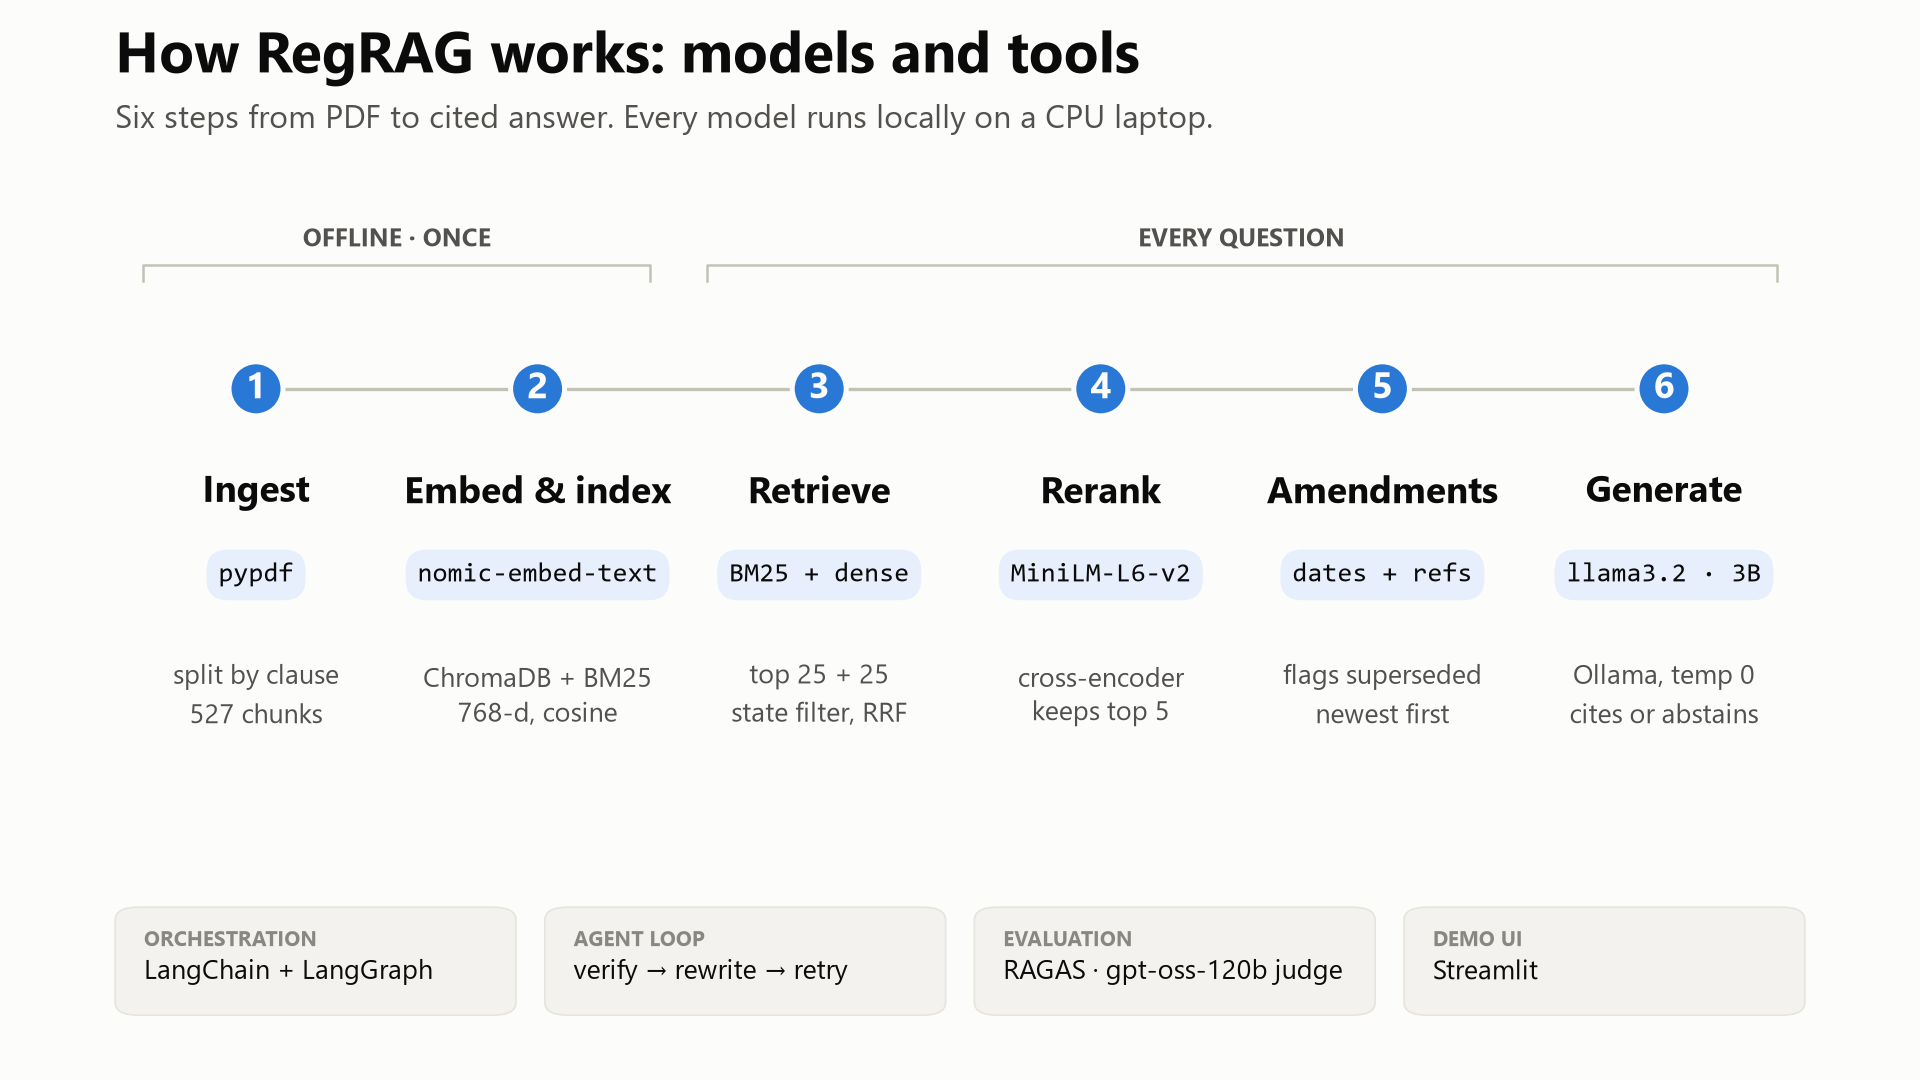

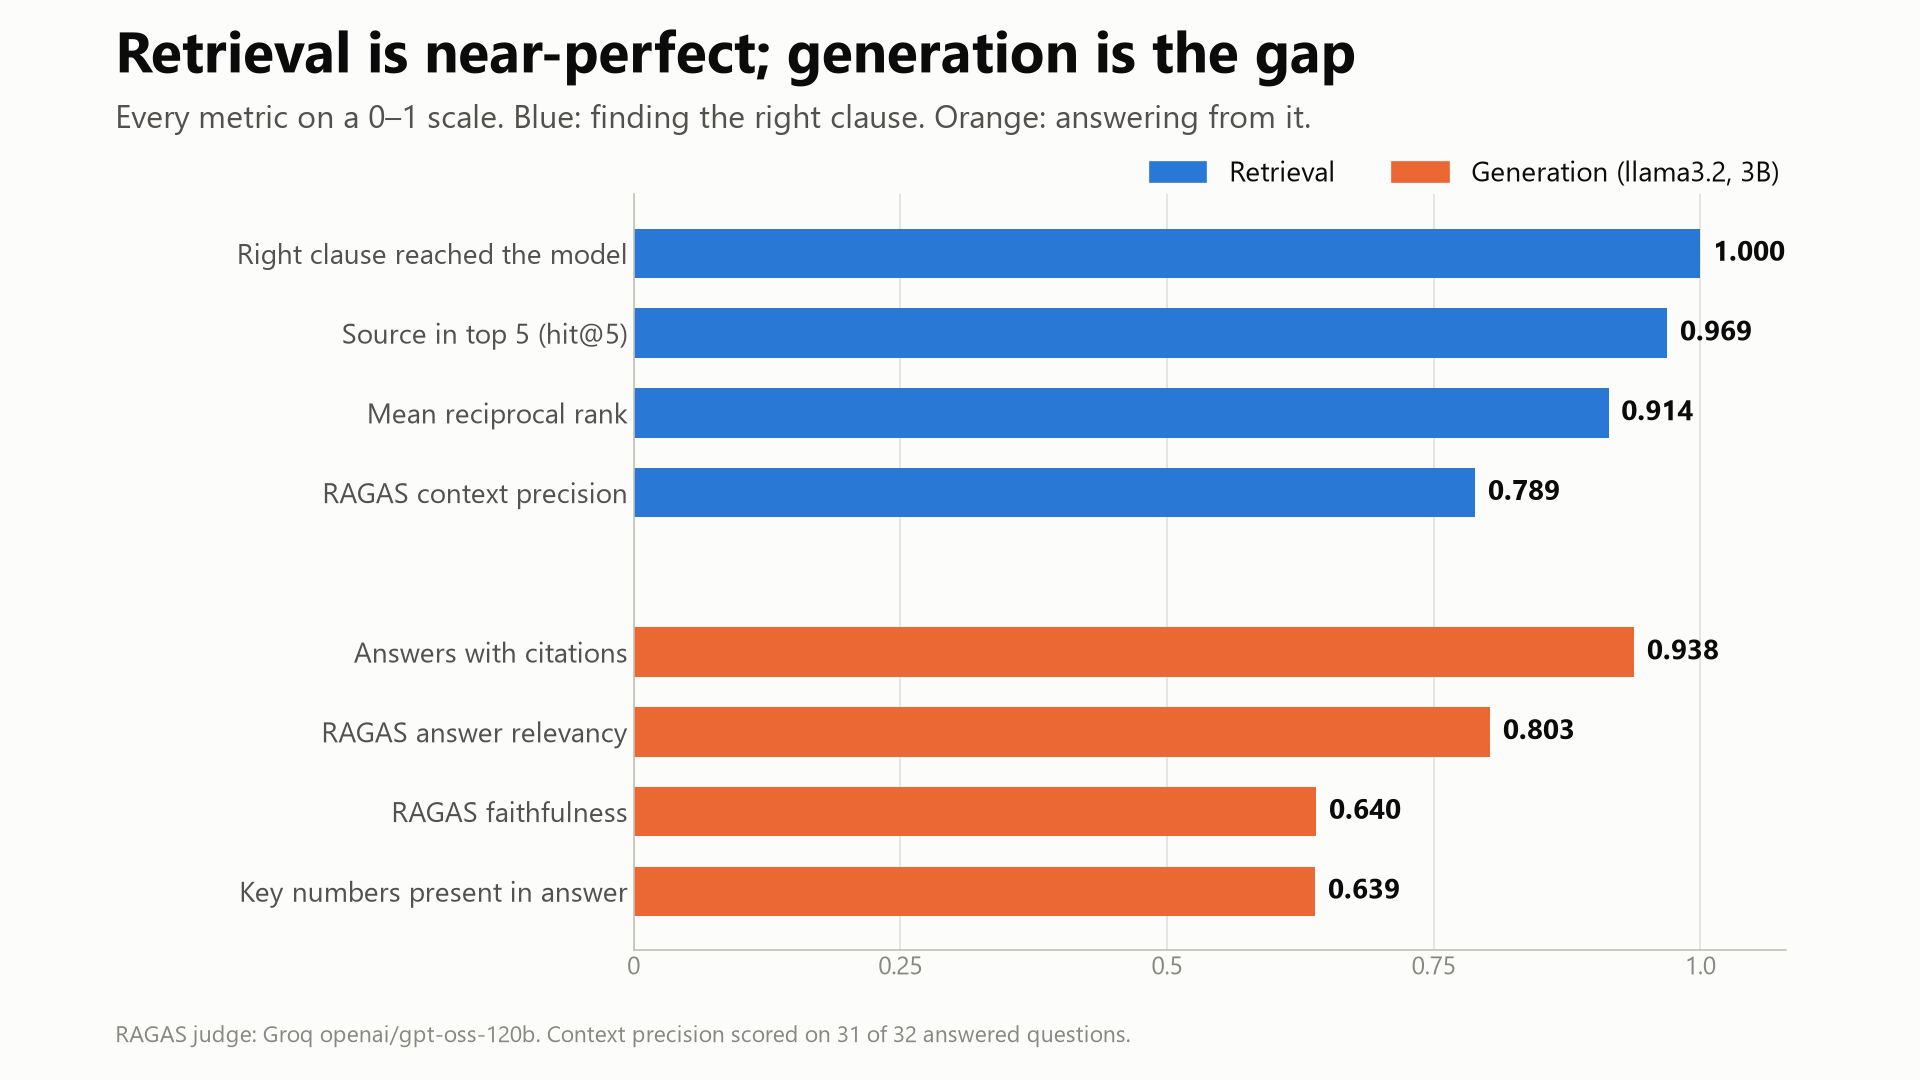

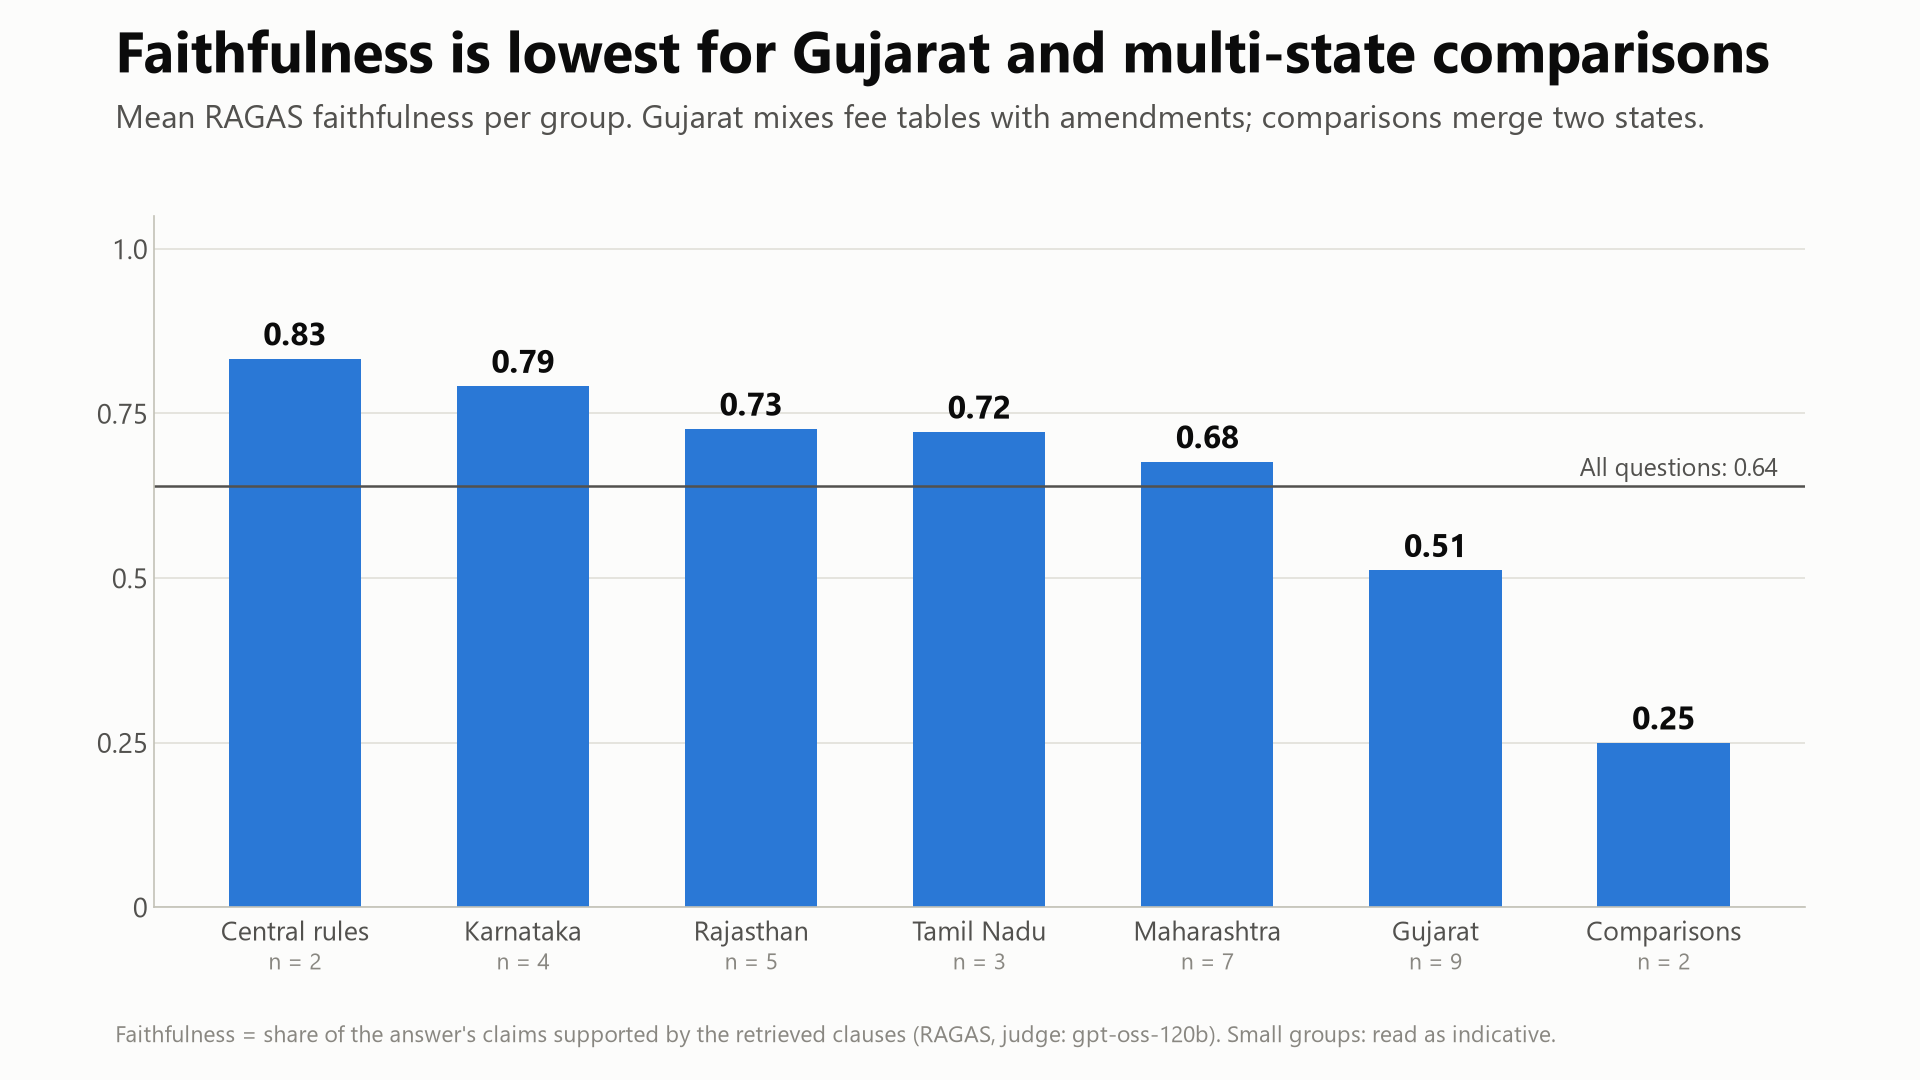

In [19]:
for name in ["08_models_and_workflow", "02_retrieval_vs_generation", "03_faithfulness_by_state"]:
    path = ROOT / "docs" / "figures" / f"{name}.png"
    if path.exists():
        display(Image(filename=str(path), width=900))
    else:
        print("missing:", path.name, "- run `python scripts/make_figures.py`")

## Summary

- **Retrieval is near-perfect.** The right clause reached the model for every test question, with
  0% cross-state contamination, thanks to clause-level chunks, the state filter, hybrid search and
  reranking.
- **Amendments are handled explicitly.** Superseded clauses are flagged and ranked below the
  provisions that replace them.
- **The answer model matters most.** With the local 3B `llama3.2`, RAGAS faithfulness was 0.64.
  Answers now come from Groq `gpt-oss-120b` by default (`LLM_PROVIDER` in `.env`), which reads the
  clauses much more reliably.